In [ ]:
%pip install egglog graphviz

In [1]:
from emap import *
from emap.rewrites import *
import egglog

def autoid():
    i = 0
    while True:
        yield egglog.i64(i)
        i += 1

In [ ]:
# Represent a 2-bit adder

egraph = egglog.EGraph()
idgen = autoid()

ins = [egraph.let(f"in[{i}]", Wire(next(idgen))) for i in range(4)]
outs = [egraph.let(f"out[{i}]", Wire(next(idgen))) for i in range(2)]
sum = egraph.let("sum", WireVec(egglog.Vec[Wire](ins[0], ins[1])) + WireVec(egglog.Vec[Wire](ins[2], ins[3])))
egraph.register(egglog.union(sum).with_(WireVec(egglog.Vec[Wire](outs[0], outs[1]))))
egraph.let("out", AsOutput("sum", sum))

egraph.display(graphviz=True)

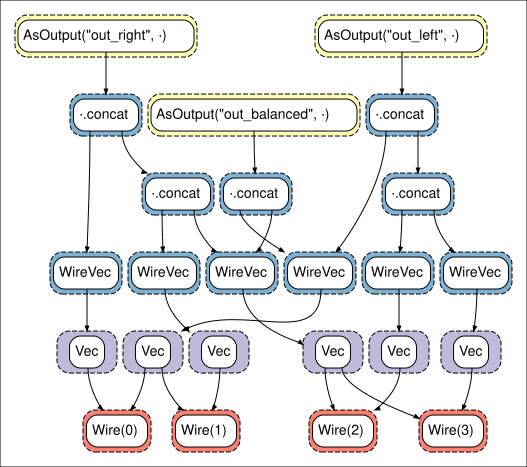

In [2]:
# Three representations of a 4-bit wirevec

egraph = egglog.EGraph()
idgen = autoid()

ins = [egraph.let(f"in[{i}]", Wire(next(idgen))) for i in range(4)]
wv_balanced = egraph.let("wv_balanced", WireVec(egglog.Vec[Wire](ins[0], ins[1])).concat(WireVec(egglog.Vec[Wire](ins[2], ins[3]))))
wv_left = egraph.let("wv_left", WireVec(egglog.Vec[Wire](ins[0], ins[1])).concat(WireVec(egglog.Vec[Wire](ins[2])).concat(WireVec(egglog.Vec[Wire](ins[3])))))
wv_right = egraph.let("wv_right", WireVec(egglog.Vec[Wire](ins[0])).concat(WireVec(egglog.Vec[Wire](ins[1])).concat(WireVec(egglog.Vec[Wire](ins[2], ins[3])))))
out_balanced = egraph.let("out_balanced", AsOutput("out_balanced", wv_balanced))
out_left = egraph.let("out_left", AsOutput("out_left", wv_left))
out_right = egraph.let("out_right", AsOutput("out_right", wv_right))

egraph.display(graphviz=True)

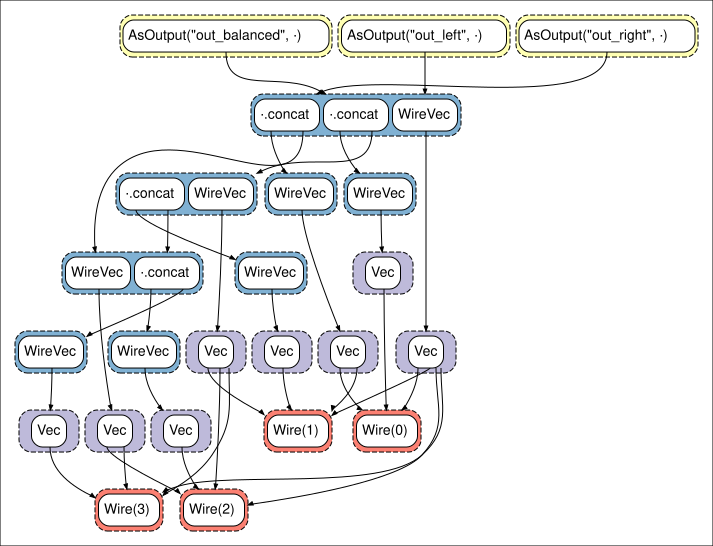

In [3]:
egraph.run(wirevec_concat_rules * 10)

egraph.check(egglog.eq(wv_balanced).to(wv_left))
egraph.check(egglog.eq(wv_balanced).to(wv_right))
egraph.display(graphviz=True)